# Homeworks 1-4 Combined

## Caleb Hadley

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew

np.random.seed(42)

### Homework 1

In [2]:
df = pd.read_csv('homework_1.1.csv')
df

,X1,X2,X3,Y
0,-0.440646,-0.390227,0.156718,-0.877671
1,-3.810099,-1.304665,-1.105117,-10.130388
2,-1.425451,-0.340049,1.115908,0.284068
3,-1.325750,0.161906,-0.254670,-1.994344
4,3.120263,1.487343,-1.164839,2.030030
...,...,...,...,...
995,1.281625,-0.062024,-0.109231,1.206058
996,-3.047558,-1.121675,0.678439,-3.229262
997,-0.028757,-0.191722,1.191790,3.160897
998,0.415266,0.373086,1.172636,4.033302


Q1. Which of the following is closest to the coefficient of X1? 

In [3]:
model = LinearRegression()

In [4]:
X = df.drop(columns='Y')
y = df['Y']

In [5]:
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
model.coef_

array([1.00713766, 1.96456859, 2.97548854])

In [7]:
model.intercept_

np.float64(0.0026430033444732604)

A1: B (1)

Q2. Which Xi has the greatest difference between the amount Y increases for each 1 unit of Xi (fixing the other Xi’s), as opposed to the amount that Y increases for each 1 unit of Xi in the dataset, on average (not fixing the other Xis)? Hint: for the former, you'll have to regress Y on Xi alone, while for the latter, you'll have to regress Y on all three Xis. 

In [8]:
conditional_slopes = dict(zip(X, model.coef_))

for col in X.columns:
    single_reg = LinearRegression()
    single_reg.fit(df[[col]], y)
    marginal_slope = single_reg.coef_[0]
    conditional_slope = conditional_slopes[col]
    diff = abs(marginal_slope - conditional_slope)
    print(f"For Column {col}, the difference is {diff}")


For Column X1, the difference is 0.834623444095558
For Column X2, the difference is 2.1190439845516598
For Column X3, the difference is 0.12155266690037037


A2: C (X2)

Q3. When regressing Y on all Xis together, which coefficient is most significant, considering the t-statistic as a measure of significance? 

In [9]:
# Calculate T statistic for each coef
y_pred = model.predict(X)
residuals = y - y_pred
for coef in model.coef_:
    print(coef)

1.0071376550759568
1.9645685948713516
2.9754885351434233


In [10]:
# Scikit-learn doesn't add a constant (intercept) by default for the math
X_with_constant = sm.add_constant(X) 
model = sm.OLS(y, X_with_constant).fit()

print(model.tvalues)

const      0.166181
X1        60.984011
X2        53.283212
X3       196.645240
dtype: float64


A3: A (X3)

In [11]:
df = pd.read_csv('homework_1.2.csv')

In [12]:
df

,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655
...,...,...,...
95,0,0.183191,0.183191
96,1,1.086513,0.586513
97,0,0.020108,0.020108
98,1,1.328940,0.828940


In [13]:
# Split the dataset based on treatment/control groups
df_0 = df[df['X'] == 0].copy()
df_1 = df[df['X'] == 1].copy()

nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
nn.fit(df_0[['Z']]) # Now we have model trained on the 0s. We can get pred for each 1 for the best 0
distances, positional_indices = nn.kneighbors(df_1[['Z']])

# Extract the true original dataframe index of the matches
matched_dataframe_indices = df_0.index[positional_indices.flatten()]

# Map the matched data back to the X = 1 dataframe
df_1['matched_X0_idx'] = matched_dataframe_indices
df_1['matched_Y'] = df_0.loc[matched_dataframe_indices, 'Y'].values
df_1['matched_Z'] = df_0.loc[matched_dataframe_indices, 'Z'].values
df_1['distance'] = distances.flatten()

df_1[['X', 'Z', 'matched_X0_idx', 'matched_Y', 'matched_Z', 'distance']].head()


,X,Z,matched_X0_idx,matched_Y,matched_Z,distance
1,1,0.715189,93,0.716327,0.716327,0.001138
5,1,0.645894,56,0.653108,0.653108,0.007214
6,1,0.437587,41,0.437032,0.437032,0.000555
7,1,0.891773,18,0.778157,0.778157,0.113616
8,1,0.963663,18,0.778157,0.778157,0.185506


In [14]:
df_1['distance'].max()

np.float64(0.2102170871093757)

In [15]:
df_1[df_1['distance'] == 0.2102170871093757]

,X,Y,Z,matched_X0_idx,matched_Y,matched_Z,distance
52,1,1.488374,0.988374,18,0.778157,0.778157,0.210217


In [16]:
# (For reflection 1)
df_1['distance'].describe(percentiles=[.25, .5, .75, .85, .95, .99])

count    48.000000
mean      0.049788
std       0.068388
min       0.000389
25%       0.002509
50%       0.013260
75%       0.055794
85%       0.150954
95%       0.198499
99%       0.205632
max       0.210217
Name: distance, dtype: float64

In [17]:
# (For reflection 1)
Q1 = df_1['distance'].quantile(0.25)
Q3 = df_1['distance'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(0.05328513303383714)

<Axes: >

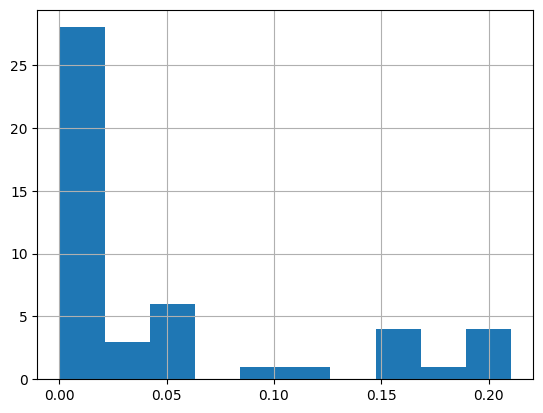

In [18]:
df_1['distance'].hist()

What is the distance of the farthest match in this set? 

Answer: np.float64(0.2102170871093757)

What is the effect? (The difference between the average Y value for X = 0 values vs. the average Y value for X = 1, where the X = 0 sample has the best match for each X = 1 value). So we use the matched sample of X = 0 and the full sample of X = 1.

In [19]:
merged_df = pd.merge(
    df_1, df_0, left_on="matched_X0_idx", right_index=True, how="inner"
)
merged_df

,X_x,Y_x,Z_x,matched_X0_idx,matched_Y,matched_Z,distance,X_y,Y_y,Z_y
1,1,1.215189,0.715189,93,0.716327,0.716327,0.001138,0,0.716327,0.716327
5,1,1.145894,0.645894,56,0.653108,0.653108,0.007214,0,0.653108,0.653108
6,1,0.937587,0.437587,41,0.437032,0.437032,0.000555,0,0.437032,0.437032
7,1,1.391773,0.891773,18,0.778157,0.778157,0.113616,0,0.778157,0.778157
8,1,1.463663,0.963663,18,0.778157,0.778157,0.185506,0,0.778157,0.778157
9,1,0.883442,0.383442,29,0.414662,0.414662,0.031220,0,0.414662,0.414662
10,1,1.291725,0.791725,18,0.778157,0.778157,0.013568,0,0.778157,0.778157
13,1,1.425597,0.925597,18,0.778157,0.778157,0.147440,0,0.778157,0.778157
17,1,1.332620,0.832620,18,0.778157,0.778157,0.054463,0,0.778157,0.778157
19,1,1.370012,0.870012,18,0.778157,0.778157,0.091855,0,0.778157,0.778157


In [20]:
merged_df['Y_x'].mean() - merged_df['Y_y'].mean()

np.float64(0.5433600652185839)

Answer: np.float64(0.5433600652185839)

How many duplicates do you end up with? (Count all but the first duplicate in each group. One way to do this is to use radius_neighbors.)

In [21]:
# Reset df1 since it had some extra columns from previous matching
df_1_new = df[df['X'] == 1].copy()

nn = NearestNeighbors(radius=0.2)
nn.fit(df_0[['Z']])
distances, indices = nn.radius_neighbors(df_1_new[['Z']]) # For all N matches within .2 radius for each X=1

# Take each N list provided by the model for all X=1 and create 1 big list (for duplicates)
all_matched_pool_indices = np.concatenate(indices)

# Same mapping strategy as before to get original df indexes
all_matched_original_indices = df_0.index[all_matched_pool_indices]

# Count the total duplicates (excluding the first occurrence of each ID)
total_matches = len(all_matched_original_indices)
unique_matches = len(np.unique(all_matched_original_indices))
duplicate_count = total_matches - unique_matches

total_matches, duplicate_count # (737 -> total, 685 -> dups)

(737, 685)

Answer: 685

What is the effect? (Note: to compute the effect, you should take the mean of the Y values in each neighbor group, then average the Y for each group.)

In [22]:
# take the mean of the Y values in each neighbor group
y_0_values = df_0['Y'].values
group_y0_means = []
valid_x1_y_values = []

# Loop through each X=1 row and its corresponding matched X=0 indices
for idx, match_indices in enumerate(indices):
    if len(match_indices) > 0:
        # take the mean of the Y values in each neighbor group
        neighbor_y_mean = y_0_values[match_indices].mean()
        group_y0_means.append(neighbor_y_mean)
        
        # Keep the matching X=1 Y value for calculating effect
        valid_x1_y_values.append(df_1_new['Y'].iloc[idx])

# average the y for each group
overall_mean_Y_X1 = np.mean(valid_x1_y_values)
overall_mean_Y_matched_X0 = np.mean(group_y0_means)
effect = overall_mean_Y_X1 - overall_mean_Y_matched_X0
effect

np.float64(0.5688516534127853)

### Homework 2

In [23]:
df = pd.read_csv('homework_2.1.csv')
df

,time,G1,G2,G3
0,0,0.882026,1.441575,0.065409
1,1,0.210079,-0.163880,0.140310
2,2,0.509369,-0.115242,0.819830
3,3,1.150447,1.014698,0.607632
4,4,0.973779,-0.046562,0.610066
...,...,...,...,...
95,95,1.303287,1.364227,1.768446
96,96,0.965250,1.845895,1.258862
97,97,1.862935,1.881752,1.511477
98,98,1.043456,2.561618,1.030275


For questions 1 and 2: 

Do a regression to estimate the fixed effect of each group. We assume that there is one single linear coefficient for all the data, plus the fixed effect of each group. Use the file homework_2.1.csv.  The variables G1, G2, and G3 are the outcomes and the time is the treatment.

In [24]:
# transform from the 3 column to single col with 3 value
df_long = pd.melt(
    df, 
    id_vars=['time'], 
    value_vars=['G1', 'G2', 'G3'], 
    var_name='group', 
    value_name='outcome'
)

# landed on this model but wasn't totally sure which is the right way based on course notes/online resource
model = smf.ols(formula="outcome ~ time + C(group)", data=df_long).fit()
# model = smf.ols(formula="outcome ~ time + C(group) - 1", data=df_long).fit()
# model = smf.ols(formula="outcome ~ time * C(group)", data=df_long).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     44.55
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           8.72e-24
Time:                        13:10:06   Log-Likelihood:                -216.89
No. Observations:                 300   AIC:                             441.8
Df Residuals:                     296   BIC:                             456.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0786      0.071      1.

In [25]:
model.params # I think intercept will be group 1?

Intercept         0.078552
C(group)[T.G2]    0.511102
C(group)[T.G3]    0.190480
time              0.009017
dtype: float64

In [26]:
common_slope = model.params['time']
group_1_data = df_long[df_long['group'] == 'G1'] # filter to group 1
group_1_coef = group_1_data['outcome'].mean() - (common_slope * group_1_data['time'].mean())
group_1_coef

np.float64(0.07855194562170326)

In [ ]:
# Adapted from week 3 nb

outcomes = ["G1", "G2", "G3"]

# demeaning
df["time_dm"] = df["time"] - df["time"].mean()

for col in outcomes:
    df[f"{col}_dm"] = df[col] - df[col].mean()

X_dm = df[["time_dm"]]

for col in outcomes:
    y_dm = df[f"{col}_dm"]
    fe_model = sm.OLS(y_dm, X_dm).fit()

    print(f"=== Fixed Effects for {col} ===")
    print(f"Coefficient on time: {fe_model.params['time_dm']:.4f}")
    print(f"Standard error: {fe_model.bse['time_dm']:.4f}\n")

=== Fixed Effects for G1 ===
Coefficient on time: 0.0085
Standard error: 0.0017

=== Fixed Effects for G2 ===
Coefficient on time: 0.0071
Standard error: 0.0018

=== Fixed Effects for G3 ===
Coefficient on time: 0.0115
Standard error: 0.0017



Q1: Which of these is closest to being the coefficient of group 1? 

In [28]:
0.00850

0.0085

Q2: Which of these is closest to being the common linear coefficient for all groups?

In [29]:
0.009017

0.009017

In [30]:
df = pd.read_csv('homework_2.2.csv')
df

,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273
...,...,...,...
9995,0,0.019371,-0.409462
9996,0,2.581533,0.545860
9997,0,0.209599,-0.486216
9998,0,16.829356,-2.045500


For questions 3-5:

Given a data set, create a bootstrap simulation to try different possibilities. 
Use the file homework_2.2.csv 

Q3: If we were to measure the effect of the treatment simply by subtracting the outcomes of the treated vs. untreated population, which of these is closest to the mean effect? (This is not the recommended way of measuring the mean effect when there are confounders!) 



In [31]:
means = df.groupby('X')[['Y', 'Z']].mean()

# diff in untreated/treated means
eff = means.loc[1] - means.loc[0]
eff

Y    2.920717
Z    0.048016
dtype: float64

Q4: If we were to use bootstrap sampling to measure the variance of that effect, again finding the effect using the non-recommended approach, which of these is closest to that variance?

In [32]:
import numpy as np
import pandas as pd

def get_treatment_effect(data):
    # diff in untreated/treated means
    means = data.groupby("X")[["Y", "Z"]].mean()
    return means.loc[1] - means.loc[0]

bootstrap_sim_trial_count = 10000
bootstrap_effects = []

for _ in range(bootstrap_sim_trial_count):
    boot_sample = df.sample(n=len(df), replace=True) # sample with replacement
    effect = get_treatment_effect(boot_sample)
    bootstrap_effects.append(effect)

bootstrap_df = pd.DataFrame(bootstrap_effects)
bootstrap_variances = bootstrap_df.var()
bootstrap_variances

Y    0.032555
Z    0.000610
dtype: float64

Q5: If we ran a linear regression (with intercept) to measure the effect, which of these is closest to the skewness of the effect measured? (Look up skewness online. You can use scipy.stats.skew to compute the skewness of a list of numbers.)

In [33]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import statsmodels.api as sm

def get_regression_effect(data):
    # Add a constant for the intercept
    X_reg = sm.add_constant(data["X"])
    model = sm.OLS(data["Y"], X_reg).fit()
    # Return the coefficient of the treatment variable X
    return model.params["X"]

bootstrap_sim_trial_count = 10_000
bootstrap_coefs = []

for _ in range(bootstrap_sim_trial_count):
    boot_sample = df.sample(n=len(df), replace=True)
    coef = get_regression_effect(boot_sample)
    bootstrap_coefs.append(coef)

effect_skewness = skew(bootstrap_coefs)
effect_skewness

np.float64(0.08210989734045372)

In [34]:
# Reflection 2 question 2

# Create pareto dist
a, m = 3., 2.  # pareto shape and mode (default values from np docs)
# sample_size = 1_000 # Variance of the sample mean: 0.002300
# sample_size = 5_000 # Variance of the sample mean: 0.000441
# sample_size = 10_000 # Variance of the sample mean: 0.000229
sample_size = 100_000 # Variance = 0.000028
s = (np.random.pareto(a, sample_size) + 1) * m

# plt.hist(s, bins=30)

bootstrap_sim_trial_count = 1000  # Number of bootstrap samples to make to be used for mean/var calculation
bootstrap_means = []

for _ in range(bootstrap_sim_trial_count):
    boot_sample = np.random.choice(s, size=sample_size, replace=True) # Sample with replacement
    boot_mean = np.mean(boot_sample)
    bootstrap_means.append(boot_mean)

variance_of_means = np.var(bootstrap_means)
print(f"{variance_of_means:.8f}")

0.00002920


### Homework 3

For questions 1 and 2: 
Given a dataset with time series data containing an event, use a linear regression to test whether there was a discontinuity in the data at the event. Consider the possibility, first, of a discontinuity only in the value of the variable but not the derivative. Then consider that there may be a discontinuity in the first derivative (the slope).  
Use the file homework_3.1.csv. 

In [35]:
df = pd.read_csv('homework_3.1.csv')
df

,time,value1,value2,value3
0,0,1.764052,1.883151,-0.369182
1,1,0.420157,-1.327759,-0.219379
2,2,1.018738,-1.230485,1.139660
3,3,2.300893,1.029397,0.715264
4,4,1.947558,-1.093123,0.720132
...,...,...,...,...
95,95,5.856573,3.628454,5.936891
96,96,5.230500,4.611791,4.937725
97,97,7.075870,4.703504,5.462954
98,98,5.486912,6.083236,4.520551


In [36]:
df.describe()

,time,value1,value2,value3
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,2.152308,1.807013,2.155768
std,29.011492,2.052524,1.557664,2.126580
min,0.000000,-2.152990,-1.327759,-1.516956
25%,24.750000,0.543743,0.963499,0.340994
50%,49.500000,1.948924,1.723450,1.816849
75%,74.250000,3.433771,2.796829,3.912036
max,99.000000,7.075870,6.083236,6.983917


In [37]:
df.isnull().sum()

time      0
value1    0
value2    0
value3    0
dtype: int64

In [38]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Create the RDD running variables
event_time = 50
df['time_centered'] = df['time'] - event_time # Centers time around the event (t=0 at cutoff)
df['after_event'] = (df['time'] >= event_time).astype(int)  # Indicator: 1 if after/at event, 0 before
df['interaction'] = df['time_centered'] * df['after_event']  # Allows slope to change post-event

value_cols = ['value1', 'value2', 'value3']

# Run RDD for each dataset
for col in value_cols:
    print(f"[{col}]")
    
    # Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)?
    model1 = smf.ols(formula=f'{col} ~ time_centered + after_event', data=df).fit()
    print("Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)?")
    print(f"pvalue for value: {model1.pvalues['after_event']:.4e}")
    print('\n')
    
    # Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)?
    # I include interaction term to add slope
    model2 = smf.ols(formula=f'{col} ~ time_centered + after_event + interaction', data=df).fit()
    print("Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)?")
    print(f"pvalue for slope: {model2.pvalues['interaction']:.4e}")
    print('\n')


[value1]
Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)?
pvalue for value: 8.5607e-02


Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)?
pvalue for slope: 3.6021e-12


[value2]
Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)?
pvalue for value: 1.1310e-01


Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)?
pvalue for slope: 1.1811e-02


[value3]
Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)?
pvalue for value: 3.2793e-05


Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)?
pvalue for slope: 2.0766e-04




Q1. Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the value at the event (at time = 50)? 


A1. value3 (intercept p value)

Q2. Which dataset is most likely to have a discontinuity (or has the strongest discontinuity) in the derivative (at time = 50)? 

A2. value1 (slope p value)

For questions 3 to 5:  
Given a dataset with treatment and control data having “before” and “after” parts, apply a differences-in-differences regression.  
Use homework_3.2.a.csv and homework_3.2.b.csv. 

In [39]:
df_a = pd.read_csv('homework_3.2.a.csv')
df_a

,group1,time1,outcome1
0,0,0,0.882026
1,0,1,1.600079
2,0,0,0.489369
3,0,1,2.520447
4,0,0,0.933779
...,...,...,...
995,1,1,4.306435
996,1,0,1.900801
997,1,1,4.147096
998,1,0,1.426195


In [40]:
df_b = pd.read_csv('homework_3.2.b.csv')
df_b

,group2,time2,outcome2
0,0,0,0.667155
1,0,1,2.470969
2,0,0,-0.506778
3,0,1,1.525657
4,0,0,0.273664
...,...,...,...
995,1,1,4.637301
996,1,0,3.681828
997,1,1,4.710121
998,1,0,0.629718


In [41]:
# Dataset A
df_a['interaction1'] = df_a['group1'] * df_a['time1']

model_a = smf.ols(
    "outcome1 ~ group1 + time1 + interaction1",
    data=df_a
).fit(cov_type="HC1")

print(model_a.summary())

# differences in differences
mean_a = df_a.groupby(['group1', 'time1'])['outcome1'].mean()
did_a = (mean_a[1][1] - mean_a[1][0]) - (mean_a[0][1] - mean_a[0][0])

print("Differences in Differences for Dataset A")
print(f"Control (0) Before (0): {mean_a[0][0]:.4f}")
print(f"Control (0) After (1):  {mean_a[0][1]:.4f}")
print(f"Treated (1) Before (0): {mean_a[1][0]:.4f}")
print(f"Treated (1) After (1):  {mean_a[1][1]:.4f}")
print(f"Treatment Effect: {did_a:.4f}")


                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2807.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:10:26   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0258      0.032     -0.808   

In [42]:
# Dataset B
df_b['interaction2'] = df_b['group2'] * df_b['time2']

# Fit the linear regression model with robust standard errors
model_b = smf.ols(
    "outcome2 ~ group2 + time2 + interaction2",
    data=df_b
).fit(cov_type="HC1")

print(model_b.summary())

# differences in differences
mean_b = df_b.groupby(['group2', 'time2'])['outcome2'].mean()
did_b = (mean_b[1][1] - mean_b[1][0]) - (mean_b[0][1] - mean_b[0][0])

print("Differences in Differences for Dataset B")
print(f"Control (0) Before (0): {mean_b[0][0]:.4f}")
print(f"Control (0) After (1):  {mean_b[0][1]:.4f}")
print(f"Treated (1) Before (0): {mean_b[1][0]:.4f}")
print(f"Treated (1) After (1):  {mean_b[1][1]:.4f}")
print(f"Treatment Effect: {did_b:.4f}")

                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     620.2
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.62e-227
Time:                        13:10:26   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.076      1.352   

In [43]:
# We know A had effect 0.6858, and B had effect 1.3499 so B is the largest effect

Q3. Which dataset likely has the largest treatment effect, assuming that the treatment and control groups have parallel trends? 

A3. Dataset 2

Q4. Using the standard errors for regression, which dataset has the most statistically significant (and nonzero) treatment effect? 

In [44]:
dataset_1_coef = model_a.params['interaction1']
dataset_1_standard_error = model_a.bse['interaction1']
dataset_1_coef, dataset_1_standard_error

(np.float64(0.6858469689823519), np.float64(0.06251264175031618))

In [45]:
dataset_2_coef = model_b.params['interaction2']
dataset_2_standard_error = model_b.bse['interaction2']
dataset_2_coef, dataset_2_standard_error

(np.float64(1.3498589246796606), np.float64(0.14703216660376472))

In [46]:
dataset_1_t_stat = dataset_1_coef / dataset_1_standard_error
dataset_2_t_stat = dataset_2_coef / dataset_2_standard_error
dataset_1_t_stat, dataset_2_t_stat

(np.float64(10.971332354209506), np.float64(9.180704847513944))

A. Dataset 1

Q5. Which of these is closest to the treatment effect for group 2? 

A5. It should be around 9.18

### Homework 4

In [47]:
df = pd.read_csv('homework_4.1.csv')
df

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796
...,...,...,...,...
4995,0,-0.976289,0.482060,-0.830112
4996,0,0.677586,-0.580264,1.106948
4997,0,-0.829560,0.895967,-0.612659
4998,0,-1.126846,-0.178558,-2.882220


In [48]:
df['W'].duplicated().any()

np.False_

Task: Given data about an instrumental variable, find the effect. X is the treatment, W the confounder, Y the outcome, and Z the instrument. Use homework_4.1.csv. 

Personal notes:

Z (instrument) influences X (treatment) but has no effect on Y (outcome) except through the treatment

I need to calculate the following and take average of W for it

(Y(Z=1, W) - Y(Z=0, W)) / (X(Z=1, W) - X(Z=0, W))

Since we don't have any duplicate W's, we need to use averages instead. We don't need to know W

Q1. Did you need to know W to do this? 

A. No

B. Yes

A1. A (No)

Q2. As in the explanation, try averaging the **Y** difference and **X** difference (over **W** and **Z**) in two ways: 

1. Subtract the average **Y** value for **Z equals 1**and **Z equals 0**. Subtract the average **X**value for **Z equals 1** and **Z equals 0**. Divide the two. 
2. Find the average **Y** value for **Z equals 1**and **Z equals 0** for a narrow range of **W**. Find the average **X**value for **Z equals 1** and **Z equals 0** for the same narrow range of **W**. Take the ratio to find the effect. Then average this over all the ranges of **W**.


For the first item, the effect is closest to: 

A: 1.5

B: 2

C: 1

D: 0.5 

In [49]:
z1 = df[df['Z'] == 1]
z0 =  df[df['Z'] == 0]

In [50]:
y_avg_z1 = z1['Y'].mean()
y_avg_z0 = z0['Y'].mean()
y_avg_z1, y_avg_z0

(np.float64(1.5334744841544254), np.float64(-0.057370742020927984))

In [51]:
x_avg_z1 = z1['X'].mean()
x_avg_z0 = z0['X'].mean()
x_avg_z1, x_avg_z0

(np.float64(1.0091964255717258), np.float64(-0.009362563574908741))

In [52]:
y_avg_z1 - y_avg_z0

np.float64(1.5908452261753534)

In [53]:
x_avg_z1 - x_avg_z0

np.float64(1.0185589891466347)

In [54]:
(y_avg_z1 - y_avg_z0) / (x_avg_z1 - x_avg_z0)

np.float64(1.5618587073765746)

A2. 1.5

2. Find the average **Y** value for **Z equals 1**and **Z equals 0** for a narrow range of **W**. Find the average **X**value for **Z equals 1** and **Z equals 0** for the same narrow range of **W**. Take the ratio to find the effect. Then average this over all the ranges of **W**.


In [55]:
df.describe()

,Z,W,X,Y
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.501400,-0.009934,0.501343,0.740279
std,0.500048,0.997779,1.127010,2.225679
min,0.000000,-3.303406,-3.404084,-7.032995
25%,0.000000,-0.697551,-0.272628,-0.787994
50%,1.000000,-0.032234,0.516908,0.718374
75%,1.000000,0.647618,1.254057,2.240705
max,1.000000,4.783257,4.693866,10.081975


<Axes: >

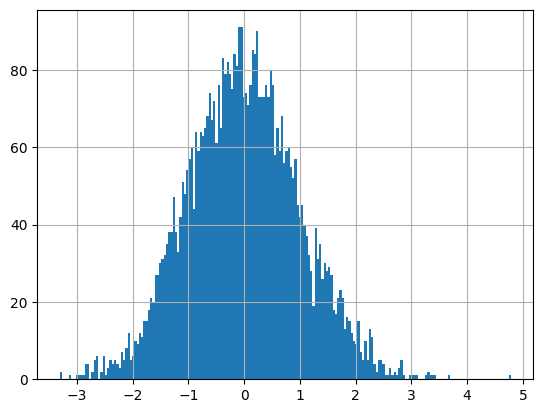

In [56]:
df['W'].hist(bins=200)

In [57]:
# Note I tried pd.cut initially but the resulting effect was wrong. I think 
# it is due to qcut makes equally sized ranges. When we calculate the effect 
# by taking mean there could have been an issue with small ranges having the 
# same effect as large ranges on the result. I picked q as 200 pretty arbitrarily 
# based on the histogram by looking at different bin counts
import numpy as np

# No labels so that it doesn't becomne a tuple in the df. 
# When we group by it goes by value so no label is needed
df["W_range"] = pd.qcut(df["W"], q=200, labels=False)

ratio_effects = []

for _, w_range_group in df.groupby("W_range"):
    w_range_z1 = w_range_group[w_range_group["Z"] == 1]
    w_range_z0 = w_range_group[w_range_group["Z"] == 0]

    # Find the average Y value for Z=1 and Z=0 for a narrow range of W.
    mean_y_z1 = w_range_z1["Y"].mean()
    mean_y_z0 = w_range_z0["Y"].mean()

    # Find the average X value for Z=1 and Z=0 for the same narrow range of W.
    mean_x_z1 = w_range_z1["X"].mean()
    mean_x_z0 = w_range_z0["X"].mean()

    # Take ratio to find the effect
    ratio_effects.append(
        (mean_y_z1 - mean_y_z0) / (mean_x_z1 - mean_x_z0)
    )

# Average this over all the ranges of W.
mean_ratio_effect = np.mean(ratio_effects)
mean_ratio_effect

np.float64(1.5204013947266082)

Task: 

Given student data involving test scores (**X**), a cutoff, and an outcome (Y), which measures whether the students got into college (as in the example in the text), determine whether the math course helps students get into college in each dataset. Use datasets homework_4.2.a and homework_4.2.b. 

In [58]:
df_a = pd.read_csv('homework_4.2.a.csv')
df_a

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1
...,...,...
99995,92.542635,1
99996,81.713212,0
99997,76.949186,0
99998,71.790575,0


In [59]:
df_b = pd.read_csv('homework_4.2.b.csv')
df_b

,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1
...,...,...
99995,75.857481,0
99996,87.572107,1
99997,81.230748,1
99998,86.646018,1


In [60]:
# I guess i'll assume 0.8 cutoff since one is not given
cutoff = 80.0

# bandwidth = 5.00  # This looks at 0.75 to 0.85
bandwidth = 1.00  # This looks at 0.79 to 0.81

# Filter the dataset to only include the score range
df_local = df_a[df_a['X'].between(cutoff - bandwidth, cutoff + bandwidth)].copy()

df_local['X_centered'] = df_local['X'] - cutoff
df_local['Treatment'] = (df_local['X'] >= cutoff).astype(int)

model = smf.ols("Y ~ X_centered * Treatment", data=df_local).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     239.6
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          6.11e-149
Time:                        13:10:27   Log-Likelihood:                -5479.1
No. Observations:                8078   AIC:                         1.097e+04
Df Residuals:                    8074   BIC:                         1.099e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3201 

In [61]:
# We can see slope decreased after treatment (slightly [-0.0165])
model.params['X_centered:Treatment']

np.float64(-0.01646485397868115)

Q3. Is **Y**'s slope higher or lower after the cutoff compared with before? 

A. Lower

B. Higher

A3. Lower (but not confident)

Q4. In that dataset, is **Y** increasing or decreasing before the cutoff? 

A. Decreasing

B. Increasing

In [62]:
# We can see 0.0262. Y is increasing (slightly) before the treatment
model.params['X_centered']

np.float64(0.026202257533137013)

A4. Increasing (but not confident)

Q5. Given a cutoff score of 80, which dataset seems most likely to involve a nonzero linear term, allowing **Y** to relate linearly to **X** before and after the cutoff? 

A. Dataset b (X2, Y2)

B. Dataset a (X, Y)

In [63]:
# Center the running variables around the cutoff (80)
df_a['X_centered'] = df_a['X'] - 80
df_a['Treatment'] = (df_a['X'] >= 80).astype(int)

df_b['X2_centered'] = df_b['X2'] - 80
df_b['Treatment'] = (df_b['X2'] >= 80).astype(int)

# Fit the models for both datasets
model_a = smf.ols('Y ~ X_centered * Treatment', data=df_a).fit()
model_b = smf.ols('Y2 ~ X2_centered * Treatment', data=df_b).fit()

In [64]:
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3300.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:10:27   Log-Likelihood:                -67412.
No. Observations:              100000   AIC:                         1.348e+05
Df Residuals:                   99996   BIC:                         1.349e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.3050 

In [65]:
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     6360.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:10:27   Log-Likelihood:                -45123.
No. Observations:              100000   AIC:                         9.025e+04
Df Residuals:                   99996   BIC:                         9.029e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.70

A5. A since p value is way lower

2. Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.

In [66]:
df_b

,X2,Y2,X2_centered,Treatment
0,76.643034,1,-3.356966,0
1,87.743397,1,7.743397,1
2,81.639469,1,1.639469,1
3,73.740485,0,-6.259515,0
4,90.480268,1,10.480268,1
...,...,...,...,...
99995,75.857481,0,-4.142519,0
99996,87.572107,1,7.572107,1
99997,81.230748,1,1.230748,1
99998,86.646018,1,6.646018,1


In [67]:
df_a[['X', 'Y']]

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1
...,...,...
99995,92.542635,1
99996,81.713212,0
99997,76.949186,0
99998,71.790575,0


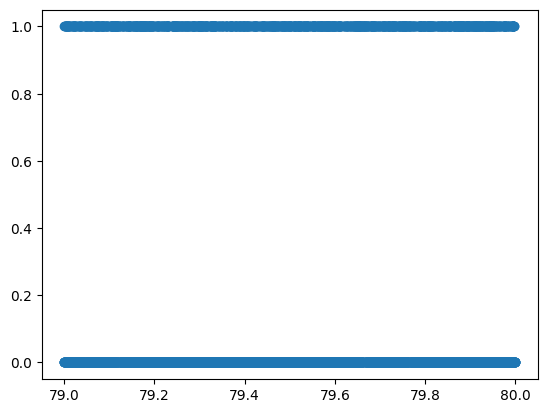

In [68]:
df_around_80 = df_a[df_a['X'].between(79,80)]

plt.scatter(df_around_80['X'], df_around_80['Y'])
None

Reflection problem:

Plot the college outcome (Y) vs. the test score (X) in a small range of test scores around 80. 

On the plot, compare it with the Y probability predicted by logistic regression. The ground truth Y value is 0 or 1; don't just plot 0 or 1 - that will make it unreadable.  Find some way to make it look better than that.

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


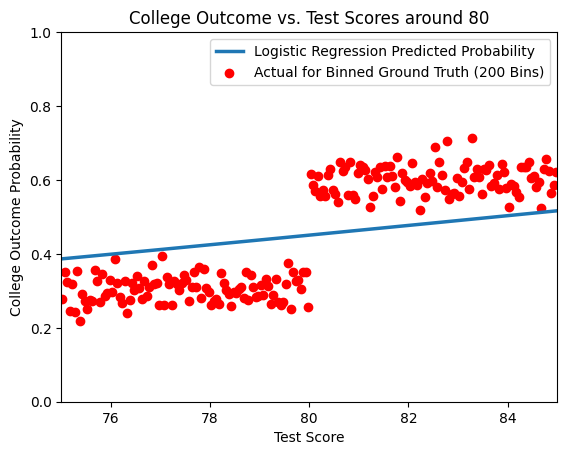

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


x_min, x_max = 75, 85  

model = LogisticRegression()
model.fit(df_a[['X']], df_a['Y'])

# Filter to only vals between 75 and 85
df_range = df_a[(df_a['X'] >= x_min) & (df_a['X'] <= x_max)].copy()

# Binning scores into groups using size 200 since otherwise there are too many dots for the graph to look good. Averaging makes it more readbale
df_range['bin'] = pd.cut(df_range['X'], bins=200)
binned_data = df_range.groupby('bin', observed=False).agg({'X': 'mean', 'Y': 'mean'}).dropna()

# Get the log reg preds to compare to the ground truth
X_smooth = np.linspace(x_min, x_max, 300).reshape(-1, 1)
Y_predicted_prob = model.predict_proba(X_smooth)[:, 1]

plt.plot(X_smooth, Y_predicted_prob, linewidth=2.5, label='Logistic Regression Predicted Probability')
plt.scatter(binned_data['X'], binned_data['Y'], color='red', label='Actual for Binned Ground Truth (200 Bins)')
plt.title('College Outcome vs. Test Scores around 80')
plt.xlabel('Test Score')
plt.ylabel('College Outcome Probability')
plt.xlim(x_min, x_max)
plt.ylim(0, 1.0)
plt.legend()
plt.show()
